1. Bag of Words
2. Tfidf

## INTRODUCTION

1. What is feature extraction from text?
2. Why do we need it?
3. Why is it difficult?
4. What is the core idea?
5. what are the Techniques?

#### We'll be learning
1. One Hot Encoding
2. bag of Words
3. Ngrams
4. tfidf
5. Custom Features
6. Word2Vec

#### Common Terms
• Corpus : Entire dataset  
• Vocabulary : All the Unique words    
• Document : Single piece of text  
• Word : Token

# One Hot Encoding

Make V dimentional vector and use 1, 0 as if that word is used or not 

#### Disadvantage
1. Sparcity : Due to sparcity overfitting happens
2. due to not equal sized input sentences, the size of the sentence changes and for ML to word we hould have the uniform size (No Fixed Size)
3. Out of Vocabulary(OOV)
4. No capturing of semantics : Similar word gets assumed different

##### Due to these problems modern NLP doest use OHE

# Bag of Words

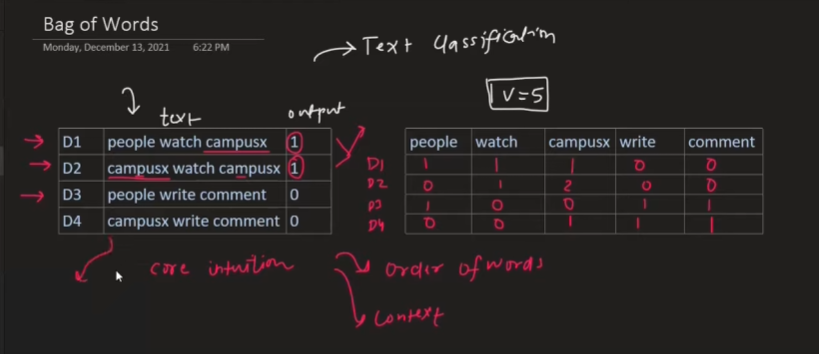

In [1]:
import numpy as np
import pandas as pd

In [4]:
df = pd.DataFrame({'text' : ['people watch campusx', 'campusx watch campusx', 'people write comment', 'campusx write comment'], 'output' : [1, 1, 0, 0]} )

In [5]:
df

,text,output
0,people watch campusx,1
1,campusx watch campusx,1
2,people write comment,0
3,campusx write comment,0


In [6]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

In [7]:
bow = cv.fit_transform(df['text'])
print(cv.vocabulary_)

{'people': 2, 'watch': 3, 'campusx': 0, 'write': 4, 'comment': 1}


In [10]:
print(bow[0].toarray())

[[1 0 1 1 0]]


In [12]:
cv.transform(["campusx watch and write comment of campusx"]).toarray()

array([[2, 1, 0, 1, 1]])

#### Advantage
1. Simple and intuitive
2. Removal of No fixed Size disadvantage of OHE
3. OOV handled
4. AS we are making vectors, Semantic relationship is being captured at some instances

#### Disadvantages
1. Sparcity
2. Out of Vocabulary words are being ignored, can miss out important words
3. In real life we are not considering the order of the words and order of words is important in the Language as same words can create new meaning by changing order of the words
4. 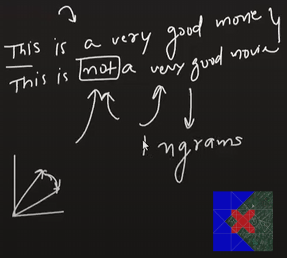

# Bag of n-grams

Here the Vocabulary of n words is used like set of n consecutive words

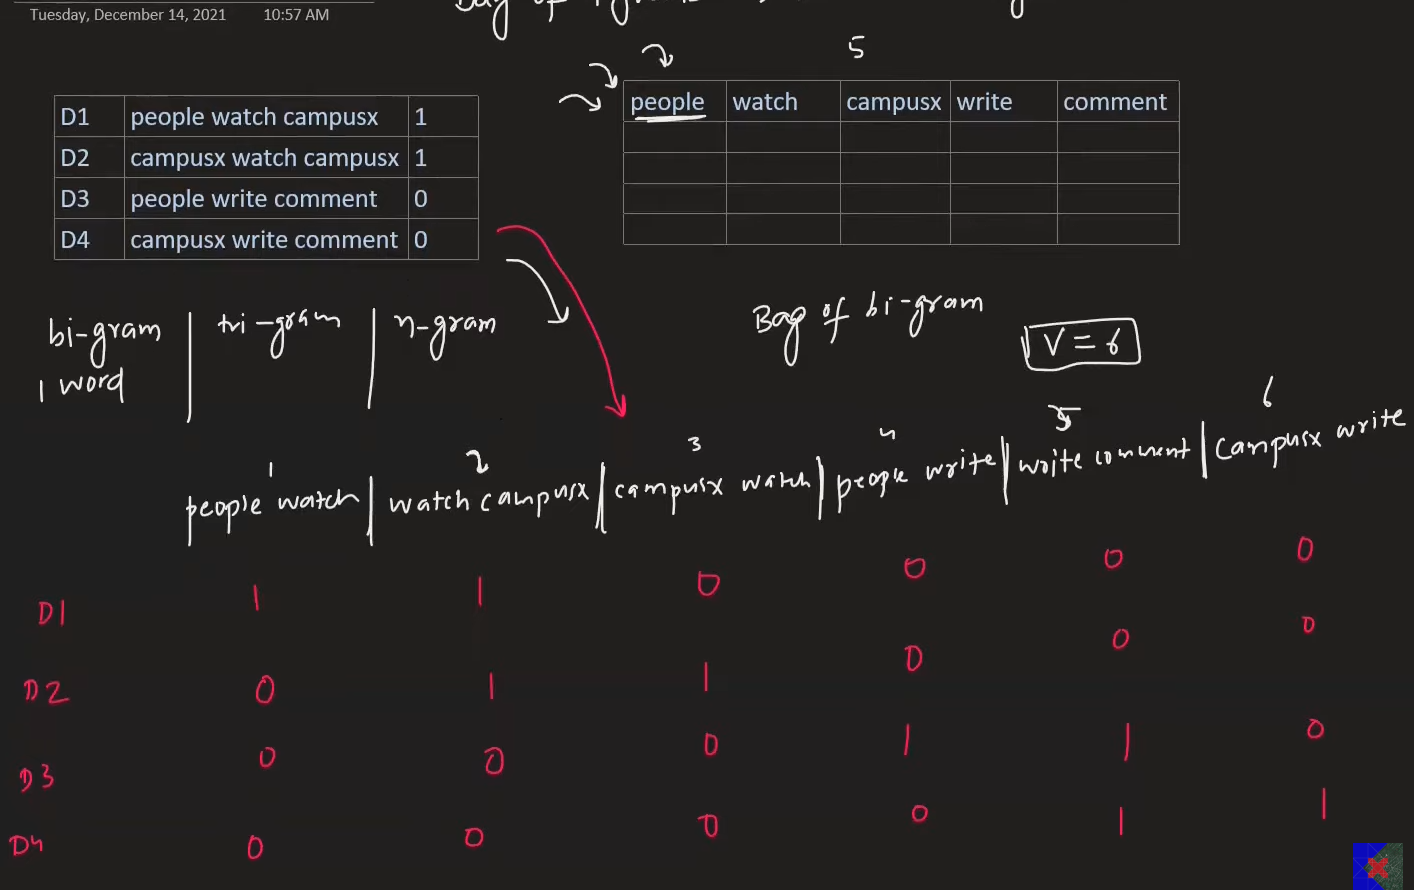

In [13]:
cv = CountVectorizer(ngram_range=(2, 2))  # For bigrams
bow = cv.fit_transform(df['text'])

In [15]:
print(cv.vocabulary_)

{'people watch': 2, 'watch campusx': 4, 'campusx watch': 0, 'people write': 3, 'write comment': 5, 'campusx write': 1}


#### Benefits
1. Semantic meaning captures in better way
2. Easy and intuitive

#### Disadvantages
1. dimentionality increaseswith the value of n and time of computation increase slowing doen the process
2. OOV no proper solution than ignoring it

# Tf-Idf

like if one word is occuring multiple times in one document but rare in corpus make it more important for that dicument and respective value is given to that word

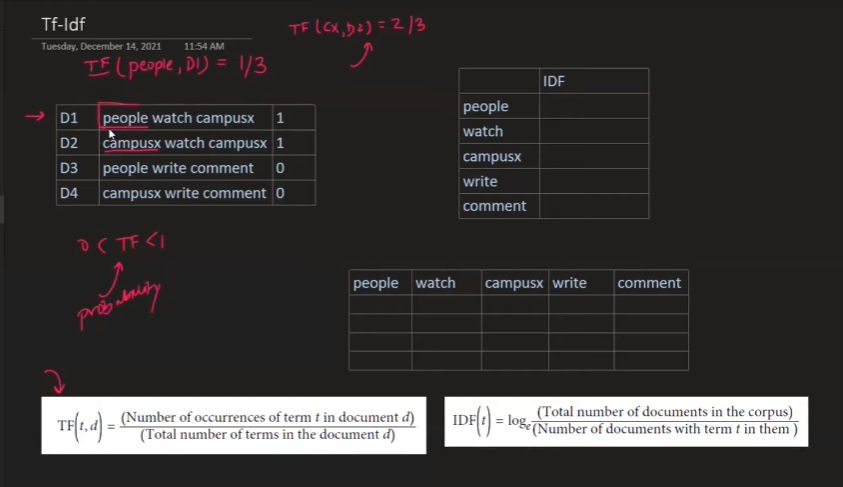

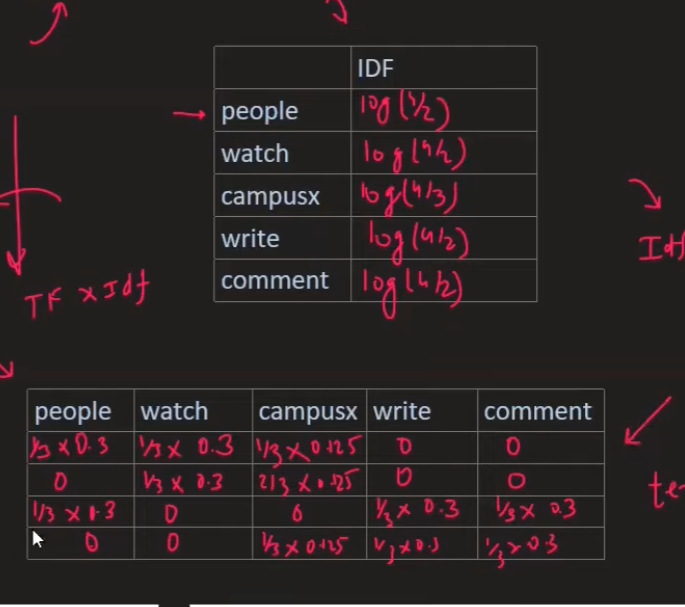

In [16]:
df

,text,output
0,people watch campusx,1
1,campusx watch campusx,1
2,people write comment,0
3,campusx write comment,0


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
tfidf.fit_transform(df['text']).toarray()

array([[0.49681612, 0.        , 0.61366674, 0.61366674, 0.        ],
       [0.8508161 , 0.        , 0.        , 0.52546357, 0.        ],
       [0.        , 0.57735027, 0.57735027, 0.        , 0.57735027],
       [0.49681612, 0.61366674, 0.        , 0.        , 0.61366674]])

In [20]:
print(tfidf.idf_)
print(tfidf.get_feature_names_out())

[1.22314355 1.51082562 1.51082562 1.51082562 1.51082562]
['campusx' 'comment' 'people' 'watch' 'write']
